In [45]:
 #  Q1 & Q2: Setup and Reproducibility
# Import required libraries following ISLP conventions
import numpy as np, pandas as pd, random, torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pytorch_lightning import seed_everything
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchinfo import summary
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from pathlib import Path

# Set seeds for reproducibility across all random number generators
# This ensures consistent results across runs
seed_everything(57, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

print("✓ All libraries imported and seeds set for reproducibility")


Seed set to 57


✓ All libraries imported and seeds set for reproducibility


In [46]:
# Q1 Part A: Data Preparation - Load and split Wage dataset
# Load the Wage dataset from ISLP package
from ISLP import load_data
Wage = load_data('Wage')

# Select features and target as specified
# Predictors: year, age, education, jobclass
# Target: wage

# Encode categorical variables (education and jobclass) using one-hot encoding
# This converts categories into binary columns that neural networks can process
X = Wage[['year', 'age', 'education', 'jobclass']].copy()
y = Wage['wage'].copy()

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=['education', 'jobclass'], drop_first=False)

print(f"Original features: {X.columns.tolist()}")
print(f"Encoded features shape: {X_encoded.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFirst few rows of encoded features:")
print(X_encoded.head())

Original features: ['year', 'age', 'education', 'jobclass']
Encoded features shape: (3000, 9)
Target shape: (3000,)

First few rows of encoded features:
   year  age  education_1. < HS Grad  education_2. HS Grad  \
0  2006   18                    True                 False   
1  2004   24                   False                 False   
2  2003   45                   False                 False   
3  2003   43                   False                 False   
4  2005   50                   False                  True   

   education_3. Some College  education_4. College Grad  \
0                      False                      False   
1                      False                       True   
2                       True                      False   
3                      False                       True   
4                      False                      False   

   education_5. Advanced Degree  jobclass_1. Industrial  \
0                         False                    True   
1

In [47]:
# Q1 Part A (continued): Split data 75/25 and standardize
# Split into training (75%) and test (25%) sets
# random_state=57 ensures reproducible splits (matching global seed)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=57
)

# Standardize features: subtract mean and divide by std
# IMPORTANT: Fit scaler ONLY on training data to prevent data leakage
# The test set should be transformed using training statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")
print(f"Number of features: {X_train_scaled.shape[1]}")


Training set size: 2250
Test set size: 750
Number of features: 9


In [48]:
# Q1 Part A (continued): Convert to PyTorch tensors and create data module
# Convert numpy arrays to PyTorch tensors with appropriate dtypes
# float32 is standard for neural network training (balance of precision and speed)
# IMPORTANT: Keep targets as 1D tensors (no reshape) for regression
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Create TensorDatasets that pair features with targets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create SimpleDataModule with 25% validation split and batch size of 64
# validation=0.25 means 25% of training data is used for validation
# batch_size=64 means the model processes 64 samples at a time
from ISLP.torch import SimpleDataModule

data_module = SimpleDataModule(train_dataset, test_dataset, validation=0.25, batch_size=64)

# Get one batch from training data to verify shapes
train_loader = data_module.train_dataloader()
X_batch, Y_batch = next(iter(train_loader))

# Relevant Prints
print(f"Training batch X shape: {X_batch.shape}")
print(f"Training batch Y shape: {Y_batch.shape}")
print(f"Input dimension: {X_batch.shape[1]}")


Training batch X shape: torch.Size([64, 9])
Training batch Y shape: torch.Size([64])
Input dimension: 9


In [49]:
# Q1 Part B: Model Definition - Neural network for wage regression
class WageModel(nn.Module):
    """
    Feedforward neural network for wage prediction.
    
    Architecture:
      - Input layer: number of features from standardized data
      - Hidden layer 1: 64 units with ReLU activation and 30% dropout
      - Hidden layer 2: 32 units with ReLU activation and 30% dropout
      - Output layer: 1 unit (continuous wage prediction)
    
    Dropout prevents overfitting by randomly deactivating neurons during training.
    ReLU (Rectified Linear Unit) adds non-linearity: f(x) = max(0, x)
    """
    def __init__(self, input_dim):
        super(WageModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(32, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        # Squeeze the last dimension to match target shape [batch_size] instead of [batch_size, 1]
        return x.squeeze(-1)


In [50]:
# Instantiate the model with correct input dimension
input_dim = X_batch.shape[1]
model = WageModel(input_dim)

# Test model with one batch to verify output shape
# Relevant Prints
model.eval()  # Set to evaluation mode for testing
with torch.no_grad():
    output = model(X_batch)
print(f"Model output shape for batch: {output.shape}")
print(f"Expected shape: ({X_batch.shape[0]},) - 1D tensor to match target shape")

# Print detailed model summary showing layers, parameters, and output shapes
print("\nModel Summary:")
print(summary(model, input_size=(64, input_dim)))


Model output shape for batch: torch.Size([64])
Expected shape: (64,) - 1D tensor to match target shape

Model Summary:
Layer (type:depth-idx)                   Output Shape              Param #
WageModel                                [64]                      --
├─Linear: 1-1                            [64, 64]                  640
├─ReLU: 1-2                              [64, 64]                  --
├─Dropout: 1-3                           [64, 64]                  --
├─Linear: 1-4                            [64, 32]                  2,080
├─ReLU: 1-5                              [64, 32]                  --
├─Dropout: 1-6                           [64, 32]                  --
├─Linear: 1-7                            [64, 1]                   33
Total params: 2,753
Trainable params: 2,753
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.01
Estimated Total Size (MB): 0.06


In [ ]:
# Q1 Part C: Training - Train the wage regression model
from ISLP.torch import SimpleModule, ErrorTracker
from pytorch_lightning.loggers import CSVLogger
from torchmetrics import MeanAbsoluteError
from torch.optim import Adam

# Create Adam optimizer with learning rate of 0.001 as specified
optimizer = Adam(model.parameters(), lr=0.001)

# Create SimpleModule for regression task
# SimpleModule.regression() automatically uses MSELoss for loss function
# metrics: Mean Absolute Error (more interpretable than MSE)
# metrics should be a dictionary, not a list
# optimizer should be passed as a keyword argument
module = SimpleModule.regression(model, metrics={'mae': MeanAbsoluteError()}, optimizer=optimizer)

# Setup logging to track training progress
# CSVLogger saves metrics to a CSV file for later analysis
# ErrorTracker monitors both training and validation errors
logger = CSVLogger('logs', name='wage_regression')
error_tracker = ErrorTracker()

# Create PyTorch Lightning Trainer
# max_epochs: number of passes through the entire training dataset
# logger: saves training history
# callbacks: ErrorTracker monitors performance
# deterministic: ensures reproducible results
from pytorch_lightning import Trainer

trainer = Trainer(
    max_epochs=100,
    logger=logger,
    callbacks=[error_tracker],
    deterministic=True
)

# Train the model
# fit() runs the training loop: forward pass, compute loss, backward pass, update weights
trainer.fit(module, data_module)

# Evaluate on test set
test_results = trainer.test(module, data_module)

# Extract and report test MAE (rounded to 2 decimal places)
# The metric name in results matches the dictionary key used in metrics
# Try different possible keys for test MAE
possible_test_keys = ['test_mae', 'test_MeanAbsoluteError']
test_mae = None
for key in possible_test_keys:
    if key in test_results[0]:
        test_mae = test_results[0][key]
        break

if test_mae is None:
    print("Available keys:", list(test_results[0].keys()))
    raise KeyError("Could not find test MAE in results")
    
print(f"\nTest MAE: {test_mae:.2f}")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | WageModel | 2.8 K  | eval 
1 | loss  | MSELoss   | 0      | train
--------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
1         Modules in train mode
8         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (27) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:527: Found 8 module(s) in eval mode at 

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.
c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │     1216.17919921875      │
│         test_mae          │    24.052385330200195     │
└───────────────────────────┴───────────────────────────┘


Test MAE: 24.05


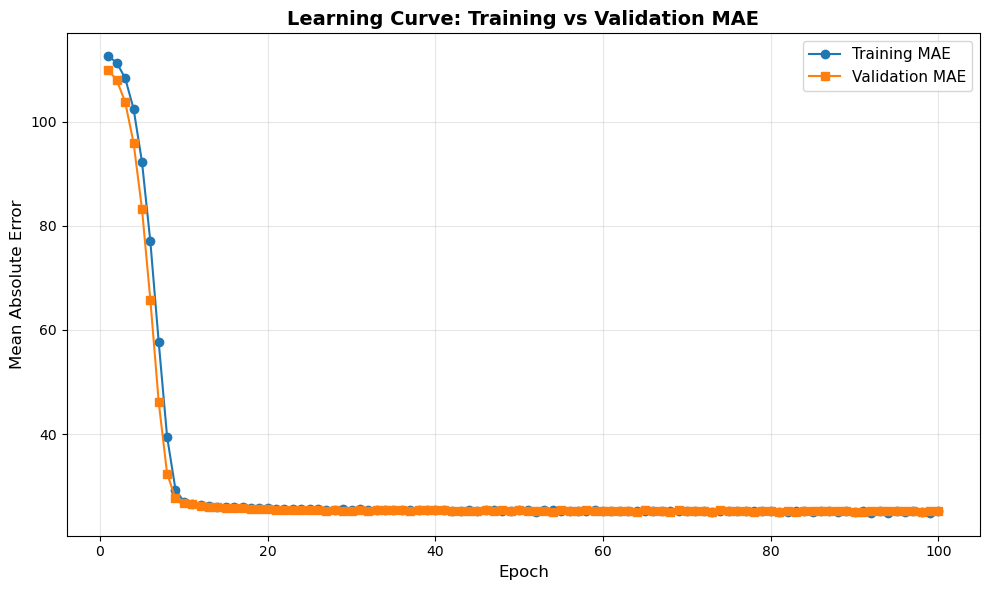


Interpretation:
The learning curve shows the training and validation MAE across epochs. 
If validation MAE is close to training MAE, the model generalizes well. 
If validation MAE is significantly higher than training MAE, the model may be overfitting.


In [53]:
# Q1 Part D: Learning Curve & Interpretation
# Load training log from CSV file saved during training
# Use the logger's experiment.metrics_file_path to get the correct version path
import os
log_dir = logger.log_dir

# Check if log_dir already contains a version directory
if os.path.basename(log_dir).startswith('version_'):
    # log_dir is already a version directory
    version_dir = log_dir
else:
    # log_dir is the base directory, need to find version directory
    version_dirs = [d for d in os.listdir(log_dir) if d.startswith('version_')]
    if version_dirs:
        version_dir = os.path.join(log_dir, sorted(version_dirs)[-1])  # Get the latest version
    else:
        raise FileNotFoundError(f"No version directories found in {log_dir}")

# Try to find metrics.csv in the version directory
metrics_file = os.path.join(version_dir, 'metrics.csv')
if not os.path.exists(metrics_file):
    # Sometimes metrics.csv might be in a subdirectory
    for root, dirs, files in os.walk(version_dir):
        if 'metrics.csv' in files:
            metrics_file = os.path.join(root, 'metrics.csv')
            break
    
if not os.path.exists(metrics_file):
    raise FileNotFoundError(f"metrics.csv not found in {version_dir} or its subdirectories")

log_df = pd.read_csv(metrics_file)

# Extract training and validation MAE across epochs
# PyTorch Lightning logs training metrics as 'train_mae_epoch' and validation as 'valid_mae'
# The metric name matches the dictionary key used in metrics (e.g., 'mae')
# Try different possible column names
possible_train_cols = ['train_mae_epoch', 'train_MeanAbsoluteError_epoch']
possible_valid_cols = ['valid_mae', 'valid_MeanAbsoluteError']

train_col = None
valid_col = None
for col in possible_train_cols:
    if col in log_df.columns:
        train_col = col
        break
for col in possible_valid_cols:
    if col in log_df.columns:
        valid_col = col
        break

if train_col is None or valid_col is None:
    print("Available columns:", log_df.columns.tolist())
    raise KeyError(f"Could not find MAE columns. Train: {train_col}, Valid: {valid_col}")

train_mae = log_df[train_col].dropna().values
valid_mae = log_df[valid_col].dropna().values
epochs = range(1, len(train_mae) + 1)

# Create learning curve plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_mae, label='Training MAE', marker='o')
plt.plot(epochs, valid_mae, label='Validation MAE', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.title('Learning Curve: Training vs Validation MAE', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('wage_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

#Interpretation (print the whole thing cleanly)
print("\nInterpretation:")
print("The learning curve shows the training and validation MAE across epochs. ")
print("If validation MAE is close to training MAE, the model generalizes well. ")
print("If validation MAE is significantly higher than training MAE, the model may be overfitting.")


In [54]:
# Q2 Part A: Data Preparation - Load image dataset
# Define image transformations following ISLP conventions
# Compose chains multiple transformations together
transform = transforms.Compose([
    transforms.Resize((64, 64)),              # Resize all images to 64x64 pixels
    transforms.ToTensor(),                     # Convert PIL Image to tensor (0-1 range)
    transforms.Normalize(mean=[0.5, 0.5, 0.5], # Normalize each RGB channel
                        std=[0.5, 0.5, 0.5])   # to range [-1, 1]
])

# Load datasets using ImageFolder
# ImageFolder expects structure: root/class_name/image_files
# It automatically assigns labels: 0 for first folder (cats), 1 for second (dogs)
train_path = 'cats_vs_dogs_dataset/train'
test_path = 'cats_vs_dogs_dataset/test'

train_image_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_image_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Create DataLoaders for batch processing
# shuffle=True randomizes training data order each epoch (prevents learning order)
# shuffle=False for test set (order doesn't matter for evaluation)
train_loader_temp = DataLoader(train_image_dataset, batch_size=64, shuffle=True)
test_loader_temp = DataLoader(test_image_dataset, batch_size=64, shuffle=False)

# Relevant Prints
print(f"Training dataset size: {len(train_image_dataset)}")
print(f"Test dataset size: {len(test_image_dataset)}")
print(f"Classes: {train_image_dataset.classes}")

# Get one batch to verify shapes + print
images_batch, labels_batch = next(iter(train_loader_temp))
print(f"\nImage batch shape: {images_batch.shape}")
print(f"Labels batch shape: {labels_batch.shape}")
print(f"Image range: [{images_batch.min():.2f}, {images_batch.max():.2f}]") 


Training dataset size: 1000
Test dataset size: 200
Classes: ['cats', 'dogs']

Image batch shape: torch.Size([64, 3, 64, 64])
Labels batch shape: torch.Size([64])
Image range: [-1.00, 1.00]


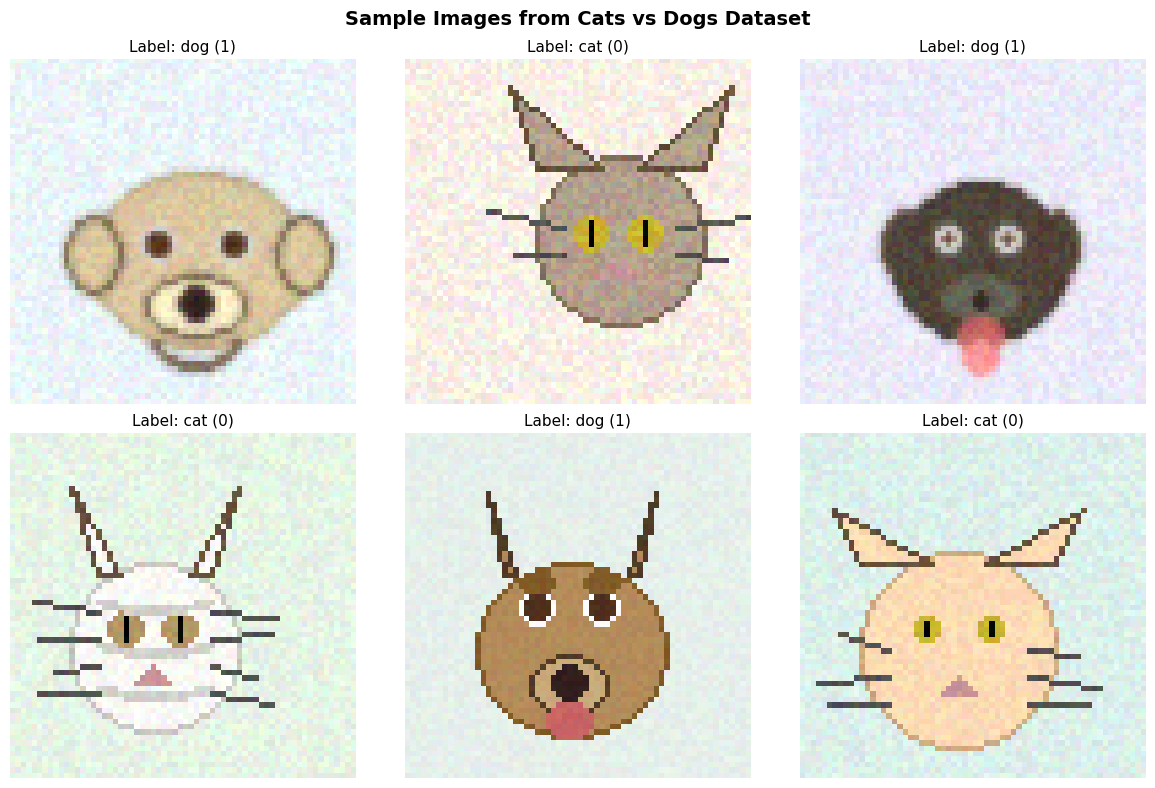

✓ Sample images displayed and saved to 'sample_images.png'


In [55]:
# Q2 Part A (continued): Display 6 sample images with labels
# Helper function to denormalize images for display
# Our normalization: (x - 0.5) / 0.5, so to reverse: x * 0.5 + 0.5
def denormalize(tensor):
    """Convert normalized tensor back to [0, 1] range for visualization"""
    return tensor * 0.5 + 0.5

# Get a batch of images and labels
images_batch, labels_batch = next(iter(train_loader_temp))

# Create figure with 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

#Loop to denormalize and plot 
class_names = ['cat', 'dog']
for i in range(6):
    img = denormalize(images_batch[i])
    img = img.permute(1, 2, 0)  # Convert from (C, H, W) to (H, W, C) for matplotlib
    label = labels_batch[i].item()
    axes[i].imshow(img.clamp(0, 1))
    axes[i].set_title(f'Label: {class_names[label]} ({label})', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Sample Images from Cats vs Dogs Dataset', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sample images displayed and saved to 'sample_images.png'")


In [56]:
# Q2 Part A (continued): Convert to TensorDataset format
# SimpleDataModule expects TensorDatasets, so we convert from ImageFolder format

# Extract all images and labels from ImageFolder datasets
def dataset_to_tensors(dataset):
    """Convert ImageFolder dataset to tensors"""
    images_list = []
    labels_list = []
    
    # Create a DataLoader to batch process
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    
    # Get all data in one batch
    for images, labels in loader:
        images_list.append(images)
        labels_list.append(labels)
    
    return torch.cat(images_list), torch.cat(labels_list)

print("Converting datasets to tensors...")
train_images, train_labels = dataset_to_tensors(train_image_dataset)
test_images, test_labels = dataset_to_tensors(test_image_dataset)

# Create TensorDatasets
train_tensor_dataset = TensorDataset(train_images, train_labels)
test_tensor_dataset = TensorDataset(test_images, test_labels)

# Create SimpleDataModule with 25% validation split
# This will automatically split training data into train/validation
data_module_cnn = SimpleDataModule(train_tensor_dataset, test_tensor_dataset, validation=0.25, batch_size=64)

#Relevant Prints
print(f"Training tensor dataset size: {len(train_tensor_dataset)}")
print(f"Test tensor dataset size: {len(test_tensor_dataset)}")
print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")

# Verify batch shape from DataModule
train_loader_cnn = data_module_cnn.train_dataloader()
X_batch_cnn, Y_batch_cnn = next(iter(train_loader_cnn))

#Relevant Prints
print(f"\nCNN Training batch X shape: {X_batch_cnn.shape}")
print(f"CNN Training batch Y shape: {Y_batch_cnn.shape}") 


Converting datasets to tensors...
Training tensor dataset size: 1000
Test tensor dataset size: 200
Train images shape: torch.Size([1000, 3, 64, 64])
Train labels shape: torch.Size([1000])

CNN Training batch X shape: torch.Size([64, 3, 64, 64])
CNN Training batch Y shape: torch.Size([64])


In [58]:
# Q2 Part B: Model Definition - Convolutional Neural Network
class CatDogCNN(nn.Module):
    """
    Convolutional Neural Network for binary image classification.
    
    Architecture:
      Conv Block 1:
        - Conv2d: 3→16 channels, 3×3 kernel, padding=1 (preserves size)
        - ReLU activation
        - MaxPool2d: 2×2 (reduces spatial size by half: 64×64 → 32×32)
      
      Conv Block 2:
        - Conv2d: 16→32 channels, 3×3 kernel, padding=1
        - ReLU activation
        - MaxPool2d: 2×2 (reduces size: 32×32 → 16×16)
      
      Fully Connected Layers:
        - Flatten: 32×16×16 = 8192 → flattened vector
        - Linear: 8192 → 128 neurons
        - ReLU activation
        - Dropout: 30% regularization
        - Linear: 128 → 2 (output logits for 2 classes)
    
    Why CNNs for images?
      - Convolutional layers detect spatial patterns (edges, textures, shapes)
      - Pooling layers reduce dimensionality while preserving features
      - Local connectivity exploits spatial structure unlike fully connected layers
    """
    def __init__(self):
        super(CatDogCNN, self).__init__()
        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        
        # Conv Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        
        # Fully Connected Layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 2)
    
    def forward(self, x):
        # Conv Block 1: 64x64 → 32x32
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Conv Block 2: 32x32 → 16x16
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Fully Connected
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [59]:
# Instantiate the model
cnn_model = CatDogCNN()

# Test with one batch + print output shape 
cnn_model.eval()  # Set to evaluation mode for testing
with torch.no_grad():
    output_cnn = cnn_model(X_batch_cnn)
print(f"CNN model output shape for batch: {output_cnn.shape}")
print(f"Expected shape: ({X_batch_cnn.shape[0]}, 2)")

#Print model summary
print("\nCNN Model Summary:")
print(summary(cnn_model, input_size=(64, 3, 64, 64)))


CNN model output shape for batch: torch.Size([64, 2])
Expected shape: (64, 2)

CNN Model Summary:
Layer (type:depth-idx)                   Output Shape              Param #
CatDogCNN                                [64, 2]                   --
├─Conv2d: 1-1                            [64, 16, 64, 64]          448
├─ReLU: 1-2                              [64, 16, 64, 64]          --
├─MaxPool2d: 1-3                         [64, 16, 32, 32]          --
├─Conv2d: 1-4                            [64, 32, 32, 32]          4,640
├─ReLU: 1-5                              [64, 32, 32, 32]          --
├─MaxPool2d: 1-6                         [64, 32, 16, 16]          --
├─Flatten: 1-7                           [64, 8192]                --
├─Linear: 1-8                            [64, 128]                 1,048,704
├─ReLU: 1-9                              [64, 128]                 --
├─Dropout: 1-10                          [64, 128]                 --
├─Linear: 1-11                           [64, 

In [60]:
# Q2 Part C: Training - Train the CNN classifier

# Create Adam optimizer with learning rate of 0.001 as specified
from torch.optim import Adam

optimizer_cnn = Adam(cnn_model.parameters(), lr=0.001)

# Create SimpleModule for classification
# num_classes=2: binary classification (cat vs dog)
# SimpleModule.classification() automatically uses:
#   - loss_fn: CrossEntropyLoss (standard for classification)
#   - metrics: Accuracy (percentage of correct predictions)
# optimizer should be passed as a keyword argument
module_cnn = SimpleModule.classification(cnn_model, num_classes=2, optimizer=optimizer_cnn)

# Setup logging
logger_cnn = CSVLogger('logs', name='cnn_classification')
error_tracker_cnn = ErrorTracker()

# Create Trainer for CNN
trainer_cnn = Trainer(
    max_epochs=30,
    logger=logger_cnn,
    callbacks=[error_tracker_cnn],
    deterministic=True
)

# Train the CNN
trainer_cnn.fit(module_cnn, data_module_cnn)

# Evaluate on test set
test_results_cnn = trainer_cnn.test(module_cnn, data_module_cnn)

# Extract and report test accuracy (rounded to 2 decimal places)
# Try different possible keys for test accuracy
possible_test_keys = ['test_Accuracy', 'test_accuracy', 'test_acc']
test_accuracy = None
for key in possible_test_keys:
    if key in test_results_cnn[0]:
        test_accuracy = test_results_cnn[0][key]
        break

if test_accuracy is None:
    print("Available keys:", list(test_results_cnn[0].keys()))
    raise KeyError("Could not find test accuracy in results")
    
print(f"\nTest Accuracy: {test_accuracy:.2f}")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type             | Params | Mode 
---------------------------------------------------
0 | model | CatDogCNN        | 1.1 M  | eval 
1 | loss  | CrossEntropyLoss | 0      | train
---------------------------------------------------
1.1 M     Trainable params
0         Non-trainable params
1.1 M     Total params
4.216     Total estimated model params size (MB)
1         Modules in train mode
12        Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (12) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:527: Found 12 module(s) in eval mode at

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.
c:\Users\kings\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │            1.0            │
│         test_loss         │   0.003076382679864764    │
└───────────────────────────┴───────────────────────────┘


Test Accuracy: 1.00


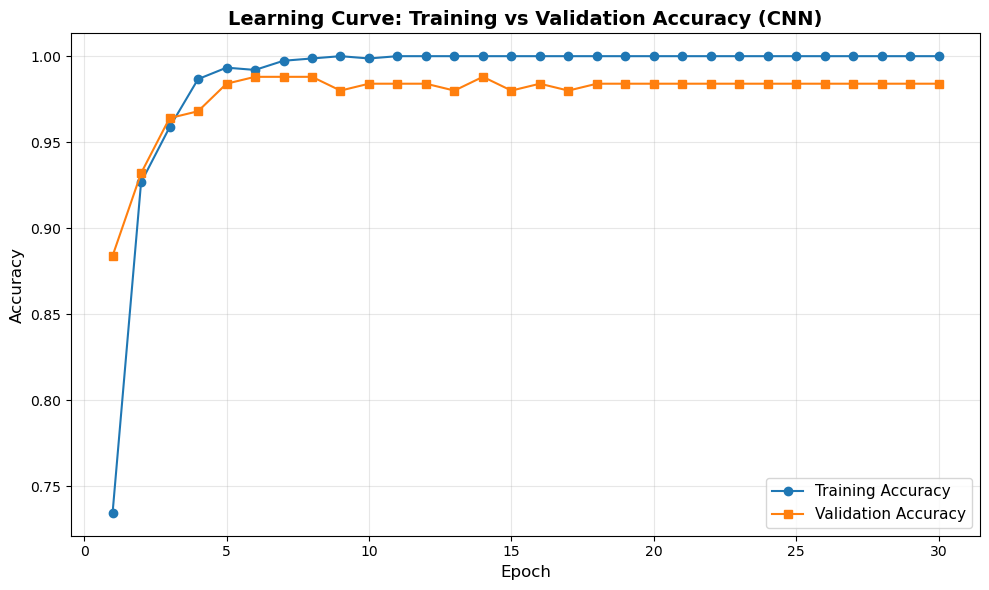


Interpretation:
CNNs handle spatial structure much better than feedforward networks for images. 
Convolutional layers can detect local patterns (edges, textures) through shared weights, 
while pooling layers reduce dimensionality while preserving spatial relationships. 
In contrast, feedforward networks in Q1 treat each pixel independently, 
losing the spatial structure that is crucial for image understanding.


In [61]:
# Q2 Part D: Learning Curve & Interpretation
# Load CNN training log from CSV file saved during training
log_dir_cnn = logger_cnn.log_dir

# Check if log_dir_cnn already contains a version directory
if os.path.basename(log_dir_cnn).startswith('version_'):
    # log_dir_cnn is already a version directory
    version_dir_cnn = log_dir_cnn
else:
    # log_dir_cnn is the base directory, need to find version directory
    version_dirs_cnn = [d for d in os.listdir(log_dir_cnn) if d.startswith('version_')]
    if version_dirs_cnn:
        version_dir_cnn = os.path.join(log_dir_cnn, sorted(version_dirs_cnn)[-1])  # Get the latest version
    else:
        raise FileNotFoundError(f"No version directories found in {log_dir_cnn}")

# Try to find metrics.csv in the version directory
metrics_file_cnn = os.path.join(version_dir_cnn, 'metrics.csv')
if not os.path.exists(metrics_file_cnn):
    # Sometimes metrics.csv might be in a subdirectory
    for root, dirs, files in os.walk(version_dir_cnn):
        if 'metrics.csv' in files:
            metrics_file_cnn = os.path.join(root, 'metrics.csv')
            break

if not os.path.exists(metrics_file_cnn):
    raise FileNotFoundError(f"metrics.csv not found in {version_dir_cnn} or its subdirectories")

log_df_cnn = pd.read_csv(metrics_file_cnn)

# Extract training and validation accuracy
# PyTorch Lightning logs training accuracy as 'train_Accuracy_epoch' and validation as 'valid_Accuracy'
# Try different possible column names
possible_train_cols = ['train_Accuracy_epoch', 'train_accuracy_epoch', 'train_acc_epoch']
possible_valid_cols = ['valid_Accuracy', 'valid_accuracy', 'valid_acc']

train_col = None
valid_col = None
for col in possible_train_cols:
    if col in log_df_cnn.columns:
        train_col = col
        break
for col in possible_valid_cols:
    if col in log_df_cnn.columns:
        valid_col = col
        break

if train_col is None or valid_col is None:
    print("Available columns:", log_df_cnn.columns.tolist())
    raise KeyError(f"Could not find accuracy columns. Train: {train_col}, Valid: {valid_col}")

train_acc = log_df_cnn[train_col].dropna().values
valid_acc = log_df_cnn[valid_col].dropna().values
epochs_cnn = range(1, len(train_acc) + 1)

# Create learning curve plot
plt.figure(figsize=(10, 6))
plt.plot(epochs_cnn, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs_cnn, valid_acc, label='Validation Accuracy', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curve: Training vs Validation Accuracy (CNN)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Interpretation (print the whole thing cleanly)
print("\nInterpretation:")
print("CNNs handle spatial structure much better than feedforward networks for images. ")
print("Convolutional layers can detect local patterns (edges, textures) through shared weights, ")
print("while pooling layers reduce dimensionality while preserving spatial relationships. ")
print("In contrast, feedforward networks in Q1 treat each pixel independently, ")
print("losing the spatial structure that is crucial for image understanding.")
